# Carga de librerías

In [1]:
from pathlib import Path
import random

import pandas as pd
import matplotlib.pyplot as plt

import torch
from unsloth import FastVisionModel
from trl import SFTConfig, SFTTrainer
from transformers import EarlyStoppingCallback
from unsloth.trainer import UnslothVisionDataCollator

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


e:\proyecto\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0523 09:43:45.643000 17792 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!


# Carga de datos

Cargamos librerías básicas y cargamos las carpetas donde encontrar la imagen y de salida.
   En este caso, ponemos la carpeta base para las imágenes procesadas, "data/processed/images".
       Como ya vimos, dentro de esta carpeta creamos un directortio `train` y otro `val` que ya tienen aplicada la división de entrenamiento / validación.
   También añadimos la carpeta de salida de los modelos, `qwen-3-vl-plants`.

In [2]:
PROJECT_ROOT = Path("E:/proyecto")
IMAGE_ROOT = PROJECT_ROOT / "data" / "processed" / "images"
OUTPUT_DIR = PROJECT_ROOT / "qwen3-vl-plants"

Recogemos las imágenes y contamos la cantidad que tenemos de validación / entrenamiento.

In [3]:
def retrieve_images(folder: Path):
    rows = []

    for image_path in sorted(folder.rglob("*.jpg")): # Accedemos a todas las imágenes JPG de forma recursiva.
        relative = image_path.relative_to(folder)

        species = relative.parts[0]
        plant_part = relative.parts[1]

        rows.append(
            {
                "image_path": str(image_path),
                "species": species,
                "plant_part": plant_part
            }
        )    

    df = pd.DataFrame(rows)
    return df

val_df = retrieve_images(IMAGE_ROOT / "val")
train_df = retrieve_images(IMAGE_ROOT / "train")

print(f"Entrenamiento: {len(train_df):,}")
print(f"Validación: {len(val_df):,}")

Entrenamiento: 2,001
Validación: 354


Y finalmente, comenzamos a preparar la información con la que aprenderá el modelo.

Como habíamos dicho, el dataset tendrá que estar en un formato "estilo conversación" que el modelo pueda entender. Para escoger el prompt del usuario, tendremos varias posibilidades para escoger.

In [4]:
user_prompts = [
    """
    Identify the plant shown in this image. The candidate plants are from the Canary Islands flora.
    Return exactly:
    Species: <latin species name>
    Plant part: <visible plant part>
    """,
    """
    You are identifying plants from Canary Islands and Macaronesian endemic flora.
    Based on the image, provide:
    Species: <latin species name>
    Plant part: <visible plant part>
    """,
    """
    Analyze this botanical image from Canary Islands vegetation and identify the most likely species and visible plant part.
    Return:
    Species: <latin species name>
    Plant part: <visible plant part>
    """,
    """
    You are identifying flora from the Canary Islands. Based on the image, provide:
    Species: <latin species name>
    Plant part: <visible plant part>
    """,
    """
    Classify this plant photo. The expected species are mostly endemic to the Canary Islands or Macaronesia.
    Do not add explanation.
    Species:
    Plant part:
    """,
    """
    Name the plant species and the visible organ in this image. The image belongs to a Canary Islands plant dataset.
    Keep the answer concise and use this schema:
    Species: <latin species name>
    Plant part: <visible plant part>
    """,
    "Identify this Canary Islands plant, please.",
    "What species from the Canary Islands flora do you think this image shows?",
    "Which Canary Islands endemic plant is visible here, and what part is shown?",
]

In [5]:
import random

def humanize(value: str) -> str:
    return value.replace("_", " ").strip().capitalize()

def make_answer(row) -> str:
    return f"Species: {humanize(row['species'])}\nPlant part: {humanize(row['plant_part'])}"

def make_messages(row):
    question = random.choice(user_prompts)
    return {
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": row["image_path"]},
                    {"type": "text", "text": question   },
                ],
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": make_answer(row)}],
            },
        ]
    }

train_dataset = train_df.apply(make_messages, axis=1)
val_dataset = val_df.apply(make_messages, axis=1)

train_dataset = train_dataset.reset_index(drop=True)
val_dataset = val_dataset.reset_index(drop=True)

val_dataset.head()

0    {'messages': [{'role': 'user', 'content': [{'t...
1    {'messages': [{'role': 'user', 'content': [{'t...
2    {'messages': [{'role': 'user', 'content': [{'t...
3    {'messages': [{'role': 'user', 'content': [{'t...
4    {'messages': [{'role': 'user', 'content': [{'t...
dtype: object

# Creación del modelo

Cargamos el modelo Qwen3-VL utilizando el objeto `FastVisionModel` de Unsloth, con el método `from_pretrained`:
*   Especificamos, primero de todo, nuestro modelo Qwen3-VL-4B.
*   Utilizando el parámetro `load_in_4bit = True`, activamos la cuantización del modelo a 4 bits.
*   `use_gradient_checkpointing = "unsloth"` permite aplicar las optimizaciones a los gradientes de Unsloth, reduciendo significativamente el uso de VRAM.

Tras esto, utilizando el método `get_peft_model` para cargar el modelo con PEFT, preparándolo para realizar fine-tuning:
*   Primero de todo, pasamos el modelo base de Qwen3-VL que acabamos de crear.
*   Especificamos las capas a las que queremos aplicar fine-tuning:
    *   `finetune_vision_layers=True`: habilita el ajuste fino de las capas encargadas de procesar la información visual de entrada, permitiendo adaptar el modelo a las imágenes nuevas de nuestro dominio (botánica local).
    *   `finetune_language_layers=True`: activa el entrenamiento de las capas de lenguaje, ajustando la generación y comprensión textual del modelo.
    *   `finetune_attention_modules=True`: permite modificar los módulos de atención, responsables de relacionar la información visual y textual para mejorar el contexto y aprender, realmente, lo necesario para identificar las especies.
    *   `finetune_mlp_modules=True`: habilita el entrenamiento de las capas MLP (Multi-Layer Perceptron), utilizadas en las transformaciones internas de las representaciones del modelo.
*   `r = 16` (rank): define el rango (tamaño) de las matrices LoRA, controlando la cantidad de parámetros adicionales que se manejan durante el entrenamiento. Valores más altos aumentan la capacidad de adaptación del modelo, pero también el consumo de memoria y tiempo de entrenamiento.
    *   16 se considera un buen valor de prueba para conversaciones multimodales (y en mi caso, ha funcionado muy bien).
*   `lora_alpha = 16` (scaling factor): ajusta el factor de escalado aplicado a las actualizaciones LoRA. Permite controlar la intensidad con la que las adaptaciones LoRA afectan a los pesos originales del modelo.
    *   Es, básicamente, un término de regularización. Se recomienda que sea igual o el doble que `r`. Nosotros lo dejamos igual porque así funciona bien.
*   `lora_dropout = 0.05` (dropout): aplica una tasa de dropout del 5% sobre las capas LoRA durante el entrenamiento. Como sabemos, esto reduce el sobreajuste (overfitting) y mejora la capacidad de generalización del modelo.
*   `bias = "none"` (bias training): indica que no se entrenarán términos de sesgo (bias) en las capas del modelo, reduciendo así el número total de parámetros ajustables y el consumo de memoria.

In [6]:
# Cargamos el modelo.
model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-4B-Instruct",
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth", # Optimiza los gradientes como optimización de Unsloth, ahorrando VRAM.
)

# Y recogemos el modelo de PEFT
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers = True,
    finetune_language_layers = True,
    finetune_attention_modules = True,
    finetune_mlp_modules = True,
    r = 16,
    lora_alpha = 16,
    lora_dropout = 0.05,
    bias = "none",
)

FastVisionModel.for_training(model)
print("Modelo preparado para fine-tuning")

==((====))==  Unsloth 2026.5.4: Fast Qwen3_Vl patching. Transformers: 5.5.0.
   \\   /|    NVIDIA GeForce RTX 3060. Num GPUs = 1. Max memory: 12.0 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.10.0+cu130. CUDA: 8.6. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 713/713 [00:04<00:00, 159.68it/s]
Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


Modelo preparado para fine-tuning


Y cargamos la configuraciones del entrenamiento y entrenador.

Para ello, empezammos configurando los parámetros de entrenamiento con `SFTConfig`:
*   `output_dir = str(OUTPUT_DIR)` (output directory): directorio donde se almacenarán los checkpoints y resultados generados durante el entrenamiento.
*   `per_device_train_batch_size = 1` (train batch size): número de muestras procesadas simultáneamente por cada GPU durante el entrenamiento.
*   `per_device_eval_batch_size = 1` (evaluation batch size): número de muestras procesadas simultáneamente por cada GPU durante la validación.
*   `gradient_accumulation_steps = 8` (gradient accumulation): acumula gradientes durante 8 pasos antes de actualizar los pesos, permitiendo simular un tamaño de batch mayor con menor consumo de memoria.
*   `warmup_steps = 30` (warmup steps): número de pasos iniciales utilizados para aumentar progresivamente la tasa de aprendizaje y estabilizar el entrenamiento.
*   `num_train_epochs = 1` (training epochs): número total de veces que el modelo recorrerá completamente el dataset de entrenamiento.
*   `learning_rate = 5e-5` (learning rate): tasa de aprendizaje utilizada por el optimizador para actualizar los pesos del modelo.
*   `logging_steps = 10` (logging frequency): frecuencia con la que se mostrarán métricas y estadísticas durante el entrenamiento.
*   `eval_strategy = "steps"` (evaluation strategy): realiza evaluaciones periódicas basadas en número de pasos de entrenamiento.
*   `eval_steps = 25` (evaluation frequency): ejecuta una validación cada 25 pasos.
*   `save_strategy = "steps"` (checkpoint strategy): guarda checkpoints periódicamente según el número de pasos.
*   `save_steps = 25` (checkpoint frequency): almacena un checkpoint del modelo cada 25 pasos.
*   `optim = "adamw_8bit"` (optimizer): utiliza el optimizador AdamW cuantizado a 8 bits para reducir el consumo de memoria.
*   `weight_decay = 0.05` (weight decay): aplica regularización L2 para reducir el sobreajuste del modelo.
*   `lr_scheduler_type = "linear"` (learning rate scheduler): reduce la tasa de aprendizaje de forma lineal a lo largo del entrenamiento.
*   `fp16` (FP16 precision): activa precisión de 16 bits en GPUs que no soportan BF16, reduciendo el consumo de memoria.
*   `bf16` (BF16 precision): utiliza precisión BF16 cuando la GPU es compatible, mejorando estabilidad y rendimiento.
*   `remove_unused_columns = False` (unused columns): mantiene todas las columnas del dataset necesarias para el procesamiento multimodal.
*   `metric_for_best_model = "eval_loss"` (best model metric): selecciona el mejor modelo utilizando la pérdida obtenida en validación.
*   `dataset_text_field = ""` (dataset text field): campo de texto vacío, ya que el procesamiento del dataset lo realiza el "data collator" de Unsloth.
*   `dataset_kwargs = {"skip_prepare_dataset": True}` (dataset configuration): evita el preprocesamiento automático del dataset.
*   `max_seq_length = 2048` (maximum sequence length): longitud máxima de secuencia que podrá procesar el modelo.
*   `load_best_model_at_end = True`: carga automáticamente el checkpoint con mejores resultados al finalizar el entrenamiento.
*   `report_to = "none"`: desactiva integraciones externas de monitorización como WandB o TensorBoard.

Tras esto, creamos el entrenador utilizando `SFTTrainer`:
*   `model = model` (base model): modelo Qwen3-VL previamente preparado para fine-tuning.
*   `tokenizer = tokenizer` (tokenizer): tokenizador asociado al modelo, encargado de convertir texto en tokens.
*   `data_collator = UnslothVisionDataCollator(model, tokenizer)` (data collator): agrupa y prepara imágenes y texto en batches compatibles con el modelo.
*   `train_dataset = train_dataset` (training dataset): conjunto de datos utilizado para entrenar el modelo.
*   `eval_dataset = val_dataset` (validation dataset): conjunto de datos utilizado para validar el rendimiento del modelo.
*   `args = training_args` (training configuration): configuración de entrenamiento definida anteriormente mediante `SFTConfig`.

Además, añadimos un callback de *Early Stopping*:
*   `early_stopping_patience = 3` (*patience*): detiene el entrenamiento si el modelo no mejora tras 3 evaluaciones consecutivas.
*   `early_stopping_threshold = 0.01` (*minimum improvement threshold*): establece la mejora mínima necesaria para considerar que el modelo sigue aprendiendo.

In [9]:
training_args = SFTConfig(
    output_dir=str(OUTPUT_DIR),
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    warmup_steps=30,
    num_train_epochs=1,
    learning_rate=5e-5,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=25,
    save_strategy="steps",
    save_steps=25,
    optim="adamw_8bit",
    weight_decay=0.05,
    lr_scheduler_type="linear",
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    remove_unused_columns=False,
    metric_for_best_model="eval_loss",
    dataset_text_field="",
    dataset_kwargs={"skip_prepare_dataset": True},
    max_seq_length=2048,
    load_best_model_at_end=True,
    report_to="tensorboard",
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=UnslothVisionDataCollator(model, tokenizer),
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    args=training_args,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience = 3,
            early_stopping_threshold = 0.01
        )
    ]
)

Unsloth: Model does not have a default image size - using 512


In [10]:
# Start training. For a quick smoke test, set training_args.max_steps above to a small value such as 5.
trainer_stats = trainer.train()
trainer_stats

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,001 | Num Epochs = 1 | Total steps = 251
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 39,321,600 of 4,477,137,408 (0.88% trained)


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
25,4.239786,3.140601
50,0.988323,0.678329
75,0.225745,0.145152
100,0.091992,0.090965
125,0.086638,0.085272
150,0.070319,0.078744
175,0.067873,0.072940


Unsloth: Restored added_tokens_decoder metadata in E:\proyecto\qwen3-vl-plants\checkpoint-25\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in E:\proyecto\qwen3-vl-plants\checkpoint-50\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in E:\proyecto\qwen3-vl-plants\checkpoint-75\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in E:\proyecto\qwen3-vl-plants\checkpoint-100\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in E:\proyecto\qwen3-vl-plants\checkpoint-125\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in E:\proyecto\qwen3-vl-plants\checkpoint-150\tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in E:\proyecto\qwen3-vl-plants\checkpoint-175\tokenizer_config.json.


TrainOutput(global_step=175, training_loss=0.9503086248465947, metrics={'train_runtime': 3112.6051, 'train_samples_per_second': 0.643, 'train_steps_per_second': 0.081, 'total_flos': 1.3657170397028352e+16, 'train_loss': 0.9503086248465947, 'epoch': 0.6996501749125438})

# Pruebas y visualización de resultados

Probamos a realizar una predicción con el modelo ahora entrenado, habilitando su modo de inferencia.

In [13]:
FastVisionModel.for_inference(model)

sample = val_dataset[random.randrange(len(val_dataset))]
sample_image = sample["messages"][0]["content"][0]["image"]
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": sample_image},
            {"type": "text", "text": random.choice(user_prompts)},
        ],
    }
]

inputs = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
).to(model.device)

with torch.inference_mode():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=64,
        do_sample=False,
        use_cache=True,
    )

generated_ids = output_ids[:, inputs["input_ids"].shape[-1]:]
prediction = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

print("Prediction:\n", prediction)
print("Expected:\n", sample["messages"][1]["content"][0]["text"])

Prediction:
 Species: Canarina canariensis
Plant part: Flower
Expected:
 Species: Canarina canariensis
Plant part: Flower


Y de la misma forma, recogemos los datos de `training_stats` para graficar el entrenamiento.

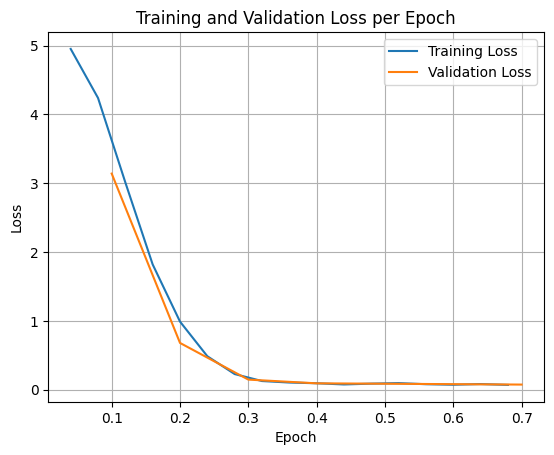

In [14]:
# Acceso a logs de historia.
log_history = trainer.state.log_history

# Extraemos pérdida y números de épocas.
train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

# Hacemos plot de los resultados de entrenamiento.
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()